In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Create your project folder structure in Drive — run this only once
base = '/content/drive/MyDrive/edtech_absa'

folders = [
    f'{base}/data/raw',
    f'{base}/data/processed',
    f'{base}/models',
    f'{base}/outputs'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Created: {folder}')

Mounted at /content/drive
Created: /content/drive/MyDrive/edtech_absa/data/raw
Created: /content/drive/MyDrive/edtech_absa/data/processed
Created: /content/drive/MyDrive/edtech_absa/models
Created: /content/drive/MyDrive/edtech_absa/outputs


In [ ]:
# CELL 1 — always run first
from google.colab import drive
drive.mount('/content/drive')

# CELL 2 — install anything not pre-installed
!pip install google-play-scraper pyabsa vaderSentiment wordcloud -q

# CELL 3 — imports
import pandas as pd
import numpy as np
# ... rest of imports

# CELL 4 — set your base path once
BASE = '/content/drive/MyDrive/edtech_absa'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.2/574.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.9 MB/s eta 0:00:00


In [ ]:
# In NB 05, after writing your app.py to Drive

# Install localtunnel (gives you a public URL for your Streamlit app)
!npm install -g localtunnel -q

# Run Streamlit in the background
!streamlit run /content/drive/MyDrive/edtech_absa/dashboard/app.py &>/content/logs.txt &

# Create a public URL
!lt --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴your url is: https://empty-adults-change.loca.lt
^C


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
base = '/content/drive/MyDrive/edtech_absa'
for folder in ['data/raw', 'data/processed', 'models', 'outputs', 'dashboard']:
    os.makedirs(f'{base}/{folder}', exist_ok=True)

print("Setup complete. Folders created.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Folders created.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/edtech_absa'
print("Base path set:", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base path set: /content/drive/MyDrive/edtech_absa


In [ ]:
!pip install google-play-scraper -q
print("Installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.9 MB/s eta 0:00:00
Installed!


In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd
import time

PLATFORMS = {
    'Coursera':          'org.coursera.android',
    'Udemy':             'com.udemy.android',
    'LinkedIn_Learning': 'com.linkedin.android',
    'edX':               'org.edx.mobile',
    'Pluralsight':       'com.pluralsight',
}

all_reviews = []

for platform_name, app_id in PLATFORMS.items():
    print(f"Fetching {platform_name}...", end=" ")

    try:
        result, _ = reviews(
            app_id,
            lang='en',
            country='us',
            sort=Sort.MOST_RELEVANT,
            count=1000,
            filter_score_with=None
        )
        for r in result:
            all_reviews.append({
                'platform':  platform_name,
                'review_id': r['reviewId'],
                'text':      r['content'],
                'rating':    r['score'],
                'date':      r['at'],
                'thumbs_up': r['thumbsUpCount']
            })
        print(f"Got {len(result)} reviews")

    except Exception as e:
        print(f"FAILED — {e}")

    time.sleep(2)

df_raw = pd.DataFrame(all_reviews)
df_raw.to_csv(f'{BASE}/data/raw/reviews_raw.csv', index=False)

print(f"\nTotal: {len(df_raw)} reviews saved to Drive")
print(df_raw['platform'].value_counts())

Fetching Coursera... Got 1000 reviews
Fetching Udemy... Got 1000 reviews
Fetching LinkedIn_Learning... Got 1000 reviews
Fetching edX... Got 1000 reviews
Fetching Pluralsight... Got 1000 reviews

Total: 5000 reviews saved to Drive
platform
Coursera             1000
Udemy                1000
LinkedIn_Learning    1000
edX                  1000
Pluralsight          1000
Name: count, dtype: int64


In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd
import time

PLATFORMS = {
    'Coursera':          'org.coursera.android',
    'Udemy':             'com.udemy.android',
    'LinkedIn_Learning': 'com.linkedin.android',
    'edX':               'org.edx.mobile',
    'Pluralsight':       'com.pluralsight',
}

# Global coverage — major regions with strong EdTech markets
COUNTRIES = {
    'us': 'North America',
    'in': 'India',           # largest EdTech market globally
    'gb': 'UK',
    'au': 'Australia',
    'ng': 'Africa',          # fast-growing EdTech region
}

all_reviews = []

for platform_name, app_id in PLATFORMS.items():
    print(f"\n{platform_name}:")

    for country_code, region_name in COUNTRIES.items():
        try:
            result, _ = reviews(
                app_id,
                lang='en',
                country=country_code,
                sort=Sort.MOST_RELEVANT,
                count=500,           # 500 per country × 5 countries = 2500 per platform
                filter_score_with=None
            )

            for r in result:
                all_reviews.append({
                    'platform':  platform_name,
                    'country':   country_code,
                    'region':    region_name,
                    'review_id': f"{platform_name}_{country_code}_{r['reviewId']}",
                    'text':      r['content'],
                    'rating':    r['score'],
                    'date':      r['at'],
                    'thumbs_up': r['thumbsUpCount']
                })
            print(f"  {region_name}: {len(result)} reviews")

        except Exception as e:
            print(f"  {region_name}: FAILED — {e}")

        time.sleep(1.5)

df_raw = pd.DataFrame(all_reviews)

# Drop duplicates across countries (same review sometimes appears in multiple regions)
df_raw = df_raw.drop_duplicates(subset=['review_id'])

df_raw.to_csv(f'{BASE}/data/raw/reviews_raw.csv', index=False)

print(f"\nTotal global reviews: {len(df_raw)}")
print("\nBy platform:")
print(df_raw['platform'].value_counts())
print("\nBy region:")
print(df_raw['region'].value_counts())


Coursera:
  North America: 500 reviews
  India: 500 reviews
  UK: 500 reviews
  Australia: 500 reviews
  Africa: 500 reviews

Udemy:
  North America: 500 reviews
  India: 500 reviews
  UK: 500 reviews
  Australia: 500 reviews
  Africa: 500 reviews

LinkedIn_Learning:
  North America: 500 reviews
  India: 500 reviews
  UK: 500 reviews
  Australia: 500 reviews
  Africa: 500 reviews

edX:
  North America: 500 reviews
  India: 500 reviews
  UK: 500 reviews
  Australia: 500 reviews
  Africa: 500 reviews

Pluralsight:
  North America: 500 reviews
  India: 500 reviews
  UK: 500 reviews
  Australia: 500 reviews
  Africa: 500 reviews

Total global reviews: 12500

By platform:
platform
Coursera             2500
Udemy                2500
LinkedIn_Learning    2500
edX                  2500
Pluralsight          2500
Name: count, dtype: int64

By region:
region
North America    2500
India            2500
UK               2500
Australia        2500
Africa           2500
Name: count, dtype: int64


In [ ]:
import re

df = pd.read_csv(f'{BASE}/data/raw/reviews_raw.csv')
print(f"Loaded {len(df)} raw reviews")

# Step 1: drop nulls and very short reviews
df = df.dropna(subset=['text'])
df = df[df['text'].str.split().str.len() >= 10]
print(f"After length filter: {len(df)}")

# Step 2: remove duplicates
df = df.drop_duplicates(subset=['review_id'])
print(f"After dedup: {len(df)}")

# Step 3: clean text
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^\w\s.,!?\'"-]', '', text)
    return text

df['text_clean'] = df['text'].apply(clean_text)
df['word_count']  = df['text_clean'].str.split().str.len()

df.to_csv(f'{BASE}/data/processed/reviews_cleaned.csv', index=False)
print(f"\nCleaned data saved. Shape: {df.shape}")
print(df[['platform','rating','word_count']].describe())

Loaded 12500 raw reviews
After length filter: 12455
After dedup: 12455

Cleaned data saved. Shape: (12455, 10)
             rating    word_count
count  12455.000000  12455.000000
mean       2.591650     58.952067
std        1.584338     25.281404
min        1.000000      9.000000
25%        1.000000     40.000000
50%        2.000000     60.000000
75%        4.000000     78.000000
max        5.000000    522.000000


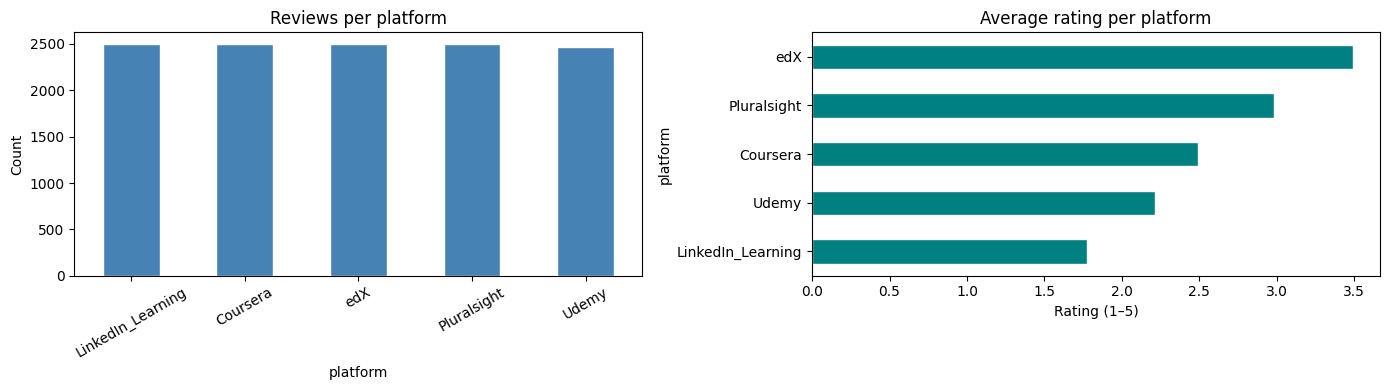

EDA chart saved to Drive


In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv(f'{BASE}/data/processed/reviews_cleaned.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: review count per platform
df['platform'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Reviews per platform')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: average rating per platform
df.groupby('platform')['rating'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('Average rating per platform')
axes[1].set_xlabel('Rating (1–5)')

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/eda_overview.png', dpi=150)
plt.show()
print("EDA chart saved to Drive")